In [1]:
##example>> Feature Scaling>> Standarddization

import numpy as np ## linear Algebra
import pandas as pd ## data processing
import matplotlib.pyplot as plt
import seaborn as sns
 

In [2]:
df=pd.read_csv("Social_Network_Ads.csv")

In [4]:
df=df.iloc[:,2:]

In [5]:
df.sample(5)

,Age,EstimatedSalary,Purchased
393,60,42000,1
369,54,26000,1
141,18,68000,0
165,18,86000,0
72,20,23000,0


In [6]:
##train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop("Purchased",axis=1),
                                               df["Purchased"],test_size=0.3,
                                               random_state=0)

In [7]:
x_train.shape, x_test.shape

((280, 2), (120, 2))

In [10]:
##Standard Scaler class
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

##fill the scaler to the train set, it will learn the parameters
scaler.fit(x_train)

##transform train and test sets

x_train_scaled = scaler.transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [12]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [13]:
##converting the arrays into data frame>> x_train_scaled is a array 
x_train_scaled= pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled= pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [14]:
x_train_scaled

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [15]:
np.round(x_train.describe())

,Age,EstimatedSalary
count,280.0,280.0
mean,38.0,69807.0
std,10.0,34641.0
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [17]:
np.round(x_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


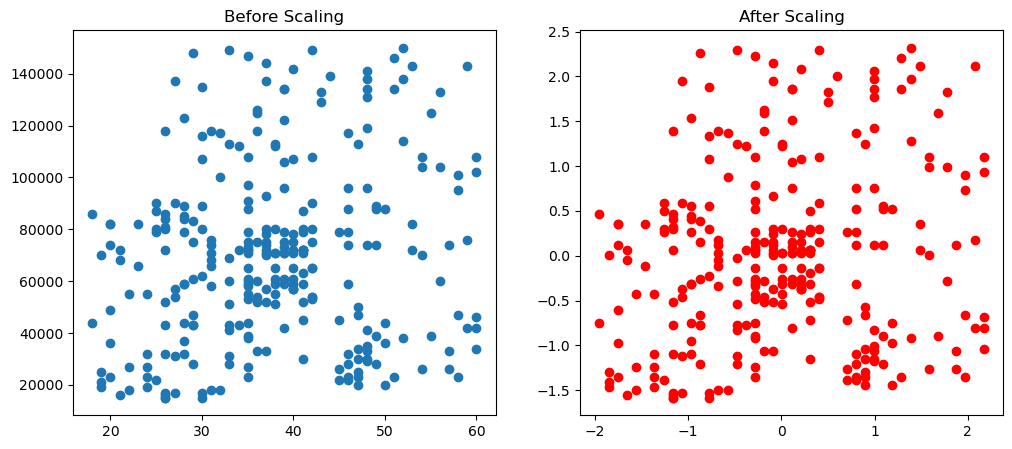

In [19]:
##Effect of Scaling
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

ax1.scatter(x_train["Age"],x_train["EstimatedSalary"])
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaled["Age"],x_train_scaled["EstimatedSalary"],color="red")
ax2.set_title("After Scaling")
plt.show()

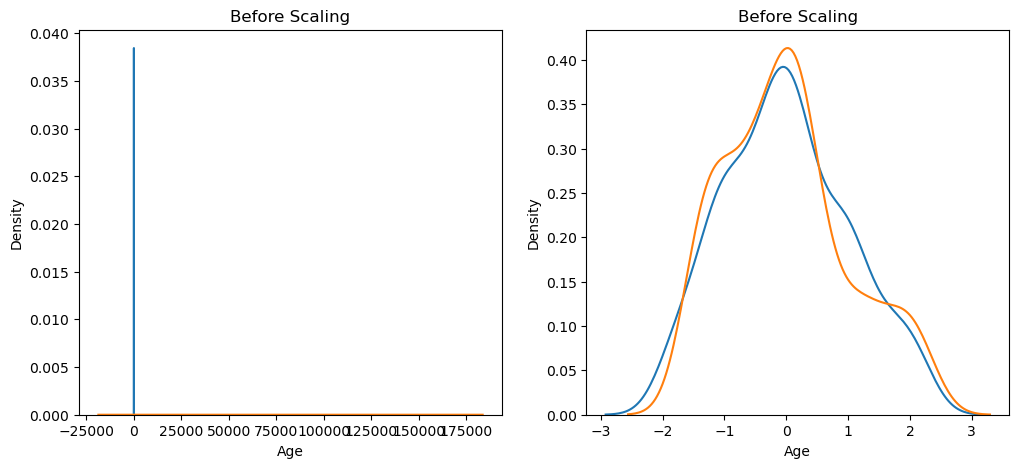

In [20]:
##probability Density Function

fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

##befor Scaling
ax1.set_title("Before Scaling")
sns.kdeplot(x_train["Age"],ax=ax1)
sns.kdeplot(x_train["EstimatedSalary"],ax=ax1)

##after Scaling
ax2.set_title("Before Scaling")
sns.kdeplot(x_train_scaled["Age"],ax=ax2)
sns.kdeplot(x_train_scaled["EstimatedSalary"],ax=ax2)
plt.show()



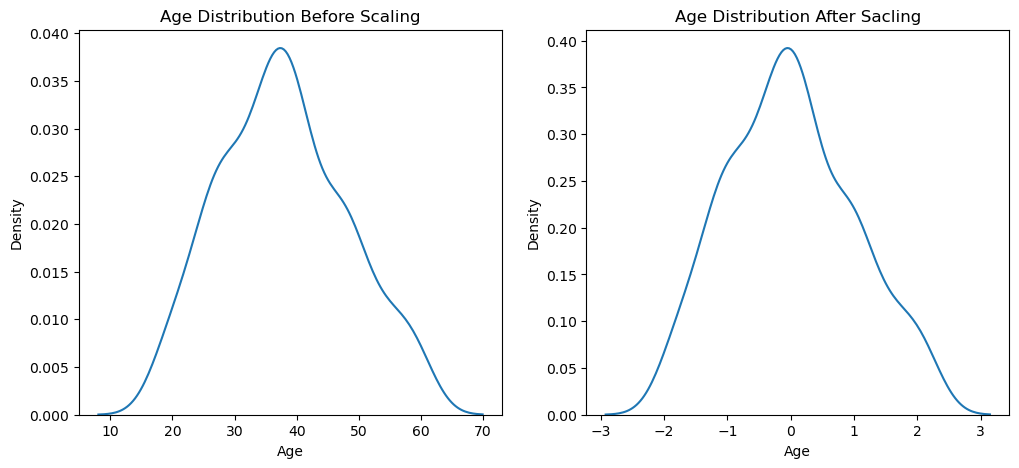

In [21]:
##comparision of distribution
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

##before Scaling
ax1.set_title("Age Distribution Before Scaling")
sns.kdeplot(x_train["Age"],ax=ax1)

##after Scaling

ax2.set_title("Age Distribution After Sacling")
sns.kdeplot(x_train_scaled["Age"],ax=ax2)
plt.show()

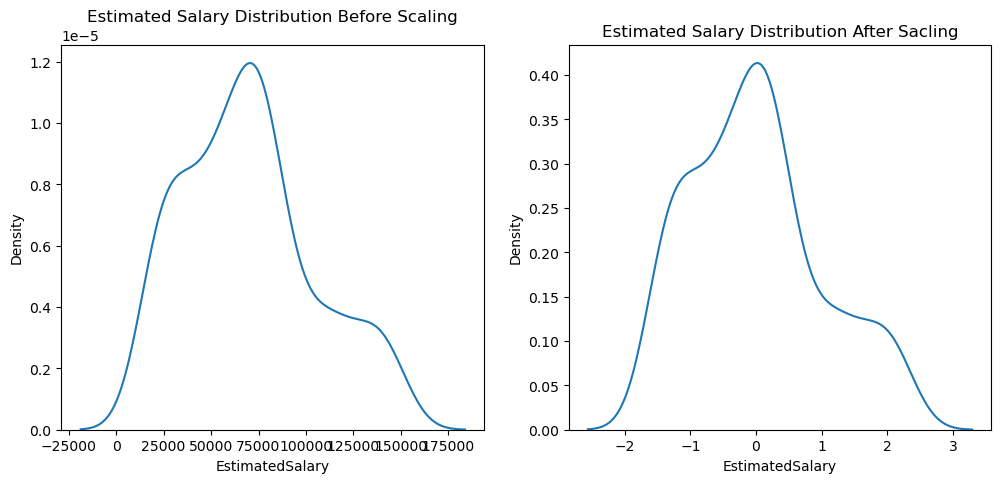

In [22]:
##comparision of distribution Salary
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

##before Scaling
ax1.set_title("Estimated Salary Distribution Before Scaling")
sns.kdeplot(x_train["EstimatedSalary"],ax=ax1)

##after Scaling

ax2.set_title("Estimated Salary Distribution After Sacling")
sns.kdeplot(x_train_scaled["EstimatedSalary"],ax=ax2)
plt.show()

In [23]:
##Why scaling is important
from sklearn.linear_model import LogisticRegression

In [24]:
lr=LogisticRegression()
lr_scaled=LogisticRegression()

In [26]:
lr.fit(x_train,y_train)
lr_scaled.fit(x_train_scaled,y_train)

LogisticRegression()

In [27]:
y_pred = lr.predict(x_test)
y_pred_scaled= lr_scaled.predict(x_test_scaled)

In [28]:
from sklearn.metrics import accuracy_score


In [30]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.875
Scaled 0.8666666666666667


In [32]:
from sklearn.tree import DecisionTreeClassifier

In [33]:
ds=DecisionTreeClassifier()
ds_scaled=DecisionTreeClassifier()

In [34]:
ds.fit(x_train,y_train)
ds_scaled.fit(x_train_scaled,y_train)

DecisionTreeClassifier()

In [35]:
y_pred=ds.predict(x_test)
y_pred_scaled=ds_scaled.predict(x_test_scaled)

In [37]:
print("Actual",accuracy_score(y_test,y_pred))
print("Sacled",accuracy_score(y_test,y_pred_scaled))
      

Actual 0.8666666666666667
Sacled 0.8666666666666667


In [38]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [ ]:
##when to use standarddization

